<a href="https://colab.research.google.com/github/SFStefenon/CNN-TFT/blob/main/CNN_TFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
epochs = 20
window_size = 120

import pandas as pd
import numpy as np
from keras import layers, models
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import random
import time
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_log_error

seed = 1
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

def performance(y_true, y_pred, time_s):
    # Calculate metrics
    rmse_v = rmse(y_true, y_pred)
    mae_v = mean_absolute_error(y_true, y_pred)
    mape_v = mean_absolute_percentage_error(y_true, y_pred)
    msle_v = mean_squared_log_error(y_true, abs(y_pred))
    # RMSE & MAE & MAPE & MSLE & time
    result = (f'{rmse_v:.2E} & {mae_v:.2E} & {mape_v:.2E} & {msle_v:.2E} & {time_s:.2E} \\\\')
    return result

# Testing architecture variation

## Load Dataset

In [ ]:
df = pd.read_csv("tucurui.csv", sep=";")
df.columns = [col.strip() for col in df.columns]
df["Data"] = pd.to_datetime(df["Data"], dayfirst=True)
df["UPH610010000"] = df["UPH610010000"].str.replace(",", ".").astype(float)
df["Natural Flow"] = df["Natural Flow"].str.replace(",", ".").astype(float)

df = df.sort_values("Data").reset_index(drop=True)
df["time_idx"] = df.index
df["group"] = "tucurui"
df = df.rename(columns={"Natural Flow": "y", "UPH610010000": "precipitation"})
#data = df[["y", "precipitation"]]
data = df[["y"]]

# convert y and precipitation to numpy arrays
data = data.to_numpy()
features = data.shape[1]

# create_dataset function
def create_dataset(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Load Dataset
X, y = create_dataset(data, window_size)

# Split into train/test sets
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, features)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, features)).reshape(X_test.shape)
y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Reshape inputs for Conv1D (samples, timesteps, features)
X_train = X_train.reshape((-1, window_size, features))
X_test = X_test.reshape((-1, window_size, features))

## Batch Normalization and Dropout

In [ ]:
# Build CNN-TFT model
inputs = layers.Input(shape=(window_size, features))

# Causal CNN for temporal pattern extraction
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

# Multi-head attention for temporal relationships
attention = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)

# Feature selection and prediction
x = layers.Concatenate()([x, attention])  # Combine CNN and attention outputs
x = layers.GlobalAveragePooling1D()(x)    # Aggregate temporal dimension
outputs = layers.Dense(1)(x)  # Predict next value
model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 24, 64)    │      1,984 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ dropout_12[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 24, 128)   │          0 │ dropout_12[0][0], │
│ (Concatenate)       │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_7[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 18,881 (73.75 KB)

 Non-trainable params: 128 (512.00 B)

## Layer Normalization

In [ ]:
# Build CNN-TFT model
inputs = layers.Input(shape=(window_size, features))

# Causal CNN for temporal pattern extraction
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(inputs)
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(x)

# Multi-head attention for temporal relationships
x_norm = layers.LayerNormalization()(x)
attention = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x_norm, x_norm)

# Feature selection and prediction
x = layers.Concatenate()([x, attention])  # Combine CNN and attention outputs
x = layers.GlobalAveragePooling1D()(x)    # Aggregate temporal dimension
outputs = layers.Dense(1)(x)  # Predict next value
model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 24, 64)    │      1,984 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 24, 64)    │     12,352 │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ conv1d_20[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 24, 128)   │          0 │ conv1d_20[0][0],  │
│ (Concatenate)       │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_8[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,809 (186.75 KB)

 Trainable params: 47,809 (186.75 KB)

 Non-trainable params: 0 (0.00 B)

## Dense Layer Stack

In [ ]:
# Build CNN-TFT model
inputs = layers.Input(shape=(window_size, features))

# Causal CNN for temporal pattern extraction
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(inputs)
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(x)

# Multi-head attention for temporal relationships
attention = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)

# Output Layers
x = layers.Dense(32, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 24, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 24, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,449 (64.25 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 0 (0.00 B)

## Deeper Convolutions

In [ ]:
# Build CNN-TFT model
inputs = layers.Input(shape=(window_size, features))

# Causal CNN for temporal pattern extraction
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(inputs)
x = layers.Conv1D(64, 3, activation='relu', padding='causal')(x)

# Multi-head attention for temporal relationships
attention = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)

# Feature selection and prediction
x = layers.Concatenate()([x, attention])  # Combine CNN and attention outputs
x = layers.GlobalAveragePooling1D()(x)    # Aggregate temporal dimension
outputs = layers.Dense(1)(x)  # Predict next value
model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 24, 64)    │      1,984 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 24, 64)    │     12,352 │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ conv1d_17[0][0],  │
│ (MultiHeadAttentio… │                   │            │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 24, 128)   │          0 │ conv1d_17[0][0],  │
│ (Concatenate)       │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_6[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,105 (121.50 KB)

 Trainable params: 31,105 (121.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train & eval

In [ ]:
# Train the model
start_time = time.time()
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)
end_time = time.time()
time_s = end_time - start_time

# Evaluate on test set
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {test_loss[1]:.4f}")
test_part = X_test[0].reshape(1, window_size, features)
test_predictions = model.predict(test_part)

# add test_predictions to the test_part
test_part = np.append(test_part, test_predictions)

# Adding window size to the predictions
for i in range(1, window_size):
    test_predictions = model.predict(test_part[-window_size:].reshape(1, window_size, features))
    test_part = np.append(test_part, test_predictions)
test_part = test_part[-window_size:].flatten()

# Calculate performance metrics
test_part = scaler.inverse_transform(test_part.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
X_test, y_test = X[split:], y[split:]
performance_metrics = performance(y_test[:window_size], test_part, time_s)
print(f"Performance metrics: {performance_metrics}")

Epoch 1/20


ValueError: Layer "functional_6" expects 2 input(s), but it received 1 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(None, 15, 1) dtype=float32>]

# Hypertuning

In [ ]:
pip -q install bayesian-optimization keras-tuner scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.8 MB/s eta 0:00:00


In [ ]:
from bayes_opt import BayesianOptimization

def objective_function(CNN_layers, num_heads, filters, kernel_size):
    CNN_layers = int(CNN_layers)
    num_heads = int(num_heads)
    filters = int(filters)
    kernel_size = int(kernel_size)

    df = pd.read_csv("tucurui.csv", sep=";")
    df.columns = [col.strip() for col in df.columns]
    df["Data"] = pd.to_datetime(df["Data"], dayfirst=True)
    df["UPH610010000"] = df["UPH610010000"].str.replace(",", ".").astype(float)
    df["Natural Flow"] = df["Natural Flow"].str.replace(",", ".").astype(float)

    df = df.sort_values("Data").reset_index(drop=True)
    df["time_idx"] = df.index
    df["group"] = "tucurui"
    df = df.rename(columns={"Natural Flow": "y", "UPH610010000": "precipitation"})
    data = df[["y"]]

    # convert y and precipitation to numpy arrays
    data = data.to_numpy()
    features = data.shape[1]

    # create_dataset function
    def create_dataset(data, window_size):
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i:i + window_size])
            y.append(data[i + window_size, 0])
        return np.array(X), np.array(y)

    # Load Dataset
    X, y = create_dataset(data, window_size)

    # Split into train/test sets
    split = int(0.8 * len(X))
    X_train, y_train = X[:split], y[:split]
    X_test, y_test = X[split:], y[split:]

    # Normalize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, features)).reshape(X_train.shape)
    X_test = scaler.transform(X_test.reshape(-1, features)).reshape(X_test.shape)
    y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
    y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

    # Reshape inputs for Conv1D (samples, timesteps, features)
    X_train = X_train.reshape((-1, window_size, features))
    X_test = X_test.reshape((-1, window_size, features))

    inputs = layers.Input(shape=(window_size, features))
    x = layers.Conv1D(filters, kernel_size, activation='relu', padding='causal')(inputs)
    for _ in range(CNN_layers):
      x = layers.Conv1D(filters, kernel_size, activation='relu', padding='causal')(x)
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=32)(x, x)
    x = layers.Concatenate()([x, attention])
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                        validation_split=0.2, verbose=1)
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    # Return negative loss (since we maximize the objective)
    return -np.sqrt(test_loss[1])

# Define parameter bounds
pbounds = {
    'CNN_layers': (1, 12),
    'num_heads': (2, 5),
    'filters': (16, 256),
    'kernel_size': (2, 5),
}

# Initialize Bayesian Optimizer
optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(init_points=5, n_iter=3)

# Get best parameters
best_params = optimizer.max
print("Best Parameters:", best_params)
Best = [int(best_params['params']['CNN_layers']), int(best_params['params']['num_heads']), int(best_params['params']['filters']), int(best_params['params']['kernel_size'])]

|   iter    |  target   | CNN_la... |  filters  | kernel... | num_heads |
-------------------------------------------------------------------------
187/187 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - loss: 0.1740 - mse: 0.1740 - val_loss: 0.0219 - val_mse: 0.0219
| 1         | -0.169    | 5.587     | 188.9     | 2.0       | 2.907     |
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.2628 - mse: 0.2628 - val_loss: 0.0247 - val_mse: 0.0247
| 2         | -0.1923   | 2.614     | 38.16     | 2.559     | 3.037     |
187/187 ━━━━━━━━━━━━━━━━━━━━ 27s 112ms/step - loss: 0.1791 - mse: 0.1791 - val_loss: 0.0266 - val_mse: 0.0266
| 3         | -0.1875   | 5.364     | 145.3     | 3.258     | 4.056     |
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.1434 - mse: 0.1434 - val_loss: 0.0179 - val_mse: 0.0179
| 4         | -0.162    | 3.249     | 226.7     | 2.082     | 4.011     |
187/187 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.1720 - mse: 0.1720 - val_loss: 0.0184 - val_mse: 0.0184
| 5        

In [ ]:
df = pd.DataFrame(data=Best, index=["CNN_layers", "num_heads", "filters", "kernel_size"])
df.to_csv('best_params.csv')

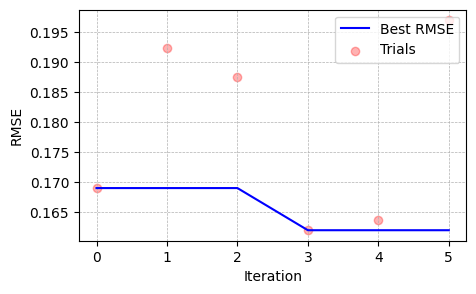

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
from scipy.interpolate import griddata
from matplotlib import cm

# Process optimization results
results = []
for i, res in enumerate(optimizer.res):
    # Cast parameters to correct types
    params = {
        'CNN_layers': int(res['params']['CNN_layers']),
        'num_heads': int(res['params']['num_heads']),
        'filters': res['params']['filters'],
        'kernel_size': res['params']['kernel_size'],
        'rmse': -res['target']  # Convert back to positive RMSE
    }
    results.append(params)

df = pd.DataFrame(results)

# 1. Convergence Plot
plt.figure(figsize=(5, 3))
df['best_rmse'] = df['rmse'].cummin()
plt.plot(df.index, df['best_rmse'], 'b-', label='Best RMSE')
plt.scatter(df.index, df['rmse'], c='r', alpha=0.3, label='Trials')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.grid(linestyle='--', linewidth=0.5)
#plt.title('Bayesian Optimization Convergence')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('Bayesian-Optimization-Convergence.pdf', bbox_inches='tight')
plt.show()

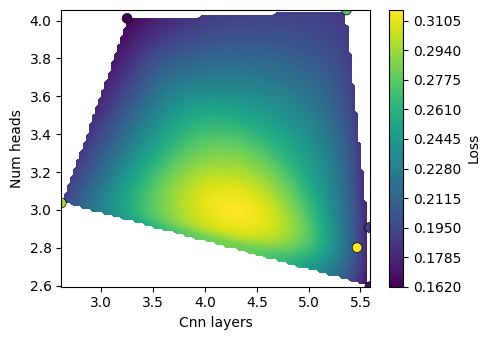

In [ ]:
# Parameters to visualize
x_param = 'CNN_layers'
y_param = 'num_heads'

# Prepare data for contour plot
x = np.array([res['params'][x_param] for res in optimizer.res])
y = np.array([res['params'][y_param] for res in optimizer.res])
z = np.array([-res['target'] for res in optimizer.res])  # RMSE values

# Create grid for smooth contour plot
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z values using Gaussian process surrogate model
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Create plot
plt.figure(figsize=(5, 3.5))
contour = plt.contourf(xi, yi, zi, levels=150, cmap=cm.viridis)
plt.colorbar(contour, label='Loss')

# Plot actual sampled points
plt.scatter(x, y, c=z, s=50, edgecolor='black', cmap=cm.viridis,
            linewidth=0.5, label='Sampled Points')

plt.xlabel(x_param.capitalize().replace('_', ' '))
plt.ylabel(y_param.capitalize().replace('_', ' '))
plt.tight_layout()
plt.savefig('Hyperparameter-Contour-Plot1.pdf', bbox_inches='tight')
plt.show()

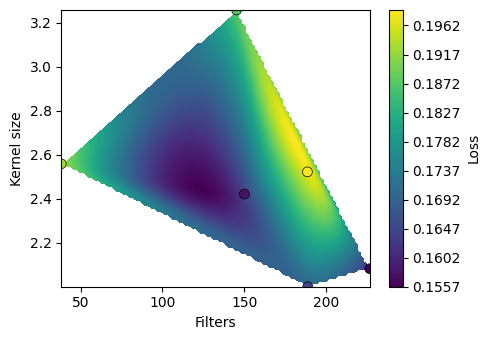

In [ ]:
# Parameters to visualize
x_param = 'filters'
y_param = 'kernel_size'

# Prepare data for contour plot
x = np.array([res['params'][x_param] for res in optimizer.res])
y = np.array([res['params'][y_param] for res in optimizer.res])
z = np.array([-res['target'] for res in optimizer.res])  # RMSE values

# Create grid for smooth contour plot
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z values using Gaussian process surrogate model
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Create plot
plt.figure(figsize=(5, 3.5))
contour = plt.contourf(xi, yi, zi, levels=150, cmap=cm.viridis)
plt.colorbar(contour, label='Loss')

# Plot actual sampled points
plt.scatter(x, y, c=z, s=50, edgecolor='black', cmap=cm.viridis,
            linewidth=0.5, label='Sampled Points')

plt.xlabel(x_param.capitalize().replace('_', ' '))
plt.ylabel(y_param.capitalize().replace('_', ' '))
plt.tight_layout()
plt.savefig('Hyperparameter-Contour-Plot2.pdf', bbox_inches='tight')
plt.show()

# Statistical Analysis

In [ ]:
CNN_layers = 3
num_heads = 4
filters = 238
kernel_size = 4

'''CNN_layers = 4
num_heads = 2
filters = 483
kernel_size = 3'''

rmse_v =[]
mae_v = []
mape_v = []
msle_v = []

for i in range(1):
  print(i)
  df = pd.read_csv("tucurui.csv", sep=";")
  df.columns = [col.strip() for col in df.columns]
  df["Data"] = pd.to_datetime(df["Data"], dayfirst=True)
  df["UPH610010000"] = df["UPH610010000"].str.replace(",", ".").astype(float)
  df["Natural Flow"] = df["Natural Flow"].str.replace(",", ".").astype(float)

  df = df.sort_values("Data").reset_index(drop=True)
  df["time_idx"] = df.index
  df["group"] = "tucurui"
  df = df.rename(columns={"Natural Flow": "y", "UPH610010000": "precipitation"})
  data = df[["y"]]

  # convert y and precipitation to numpy arrays
  data = data.to_numpy()
  features = data.shape[1]

  # create_dataset function
  def create_dataset(data, window_size):
      X, y = [], []
      for i in range(len(data) - window_size):
          X.append(data[i:i + window_size])
          y.append(data[i + window_size, 0])
      return np.array(X), np.array(y)

  # Load Dataset
  X, y = create_dataset(data, window_size)

  # Split into train/test sets
  split = int(0.8 * len(X))
  X_train, y_train = X[:split], y[:split]
  X_test, y_test = X[split:], y[split:]

  # Normalize the data
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train.reshape(-1, features)).reshape(X_train.shape)
  X_test = scaler.transform(X_test.reshape(-1, features)).reshape(X_test.shape)
  y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
  y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

  # Reshape inputs for Conv1D (samples, timesteps, features)
  X_train = X_train.reshape((-1, window_size, features))
  X_test = X_test.reshape((-1, window_size, features))

  inputs = layers.Input(shape=(window_size, features))
  x = layers.Conv1D(filters, kernel_size, activation='relu', padding='causal')(inputs)
  for _ in range(CNN_layers):
    x = layers.Conv1D(filters, kernel_size, activation='relu', padding='causal')(x)
  attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=32)(x, x)
  x = layers.Concatenate()([x, attention])
  x = layers.GlobalAveragePooling1D()(x)
  outputs = layers.Dense(1)(x)
  model = models.Model(inputs, outputs)
  model.compile(optimizer='adam', loss='mse', metrics=['mse'])
  start_time = time.time()
  history = model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                      validation_split=0.2, verbose=1)
  end_time = time.time()
  time_s = end_time - start_time
  test_loss = model.evaluate(X_test, y_test, verbose=0)
  print(f"Loss: {test_loss[1]:.4f}")
  test_part = X_test[0].reshape(1, window_size, features)
  test_predictions = model.predict(test_part)

  # add test_predictions to the test_part
  test_part = np.append(test_part, test_predictions)

  # Adding window size to the predictions
  for i in range(1, window_size):
      test_predictions = model.predict(test_part[-window_size:].reshape(1, window_size, features))
      test_part = np.append(test_part, test_predictions)
  test_part = test_part[-window_size:].flatten()

  # Calculate performance metrics
  test_part = scaler.inverse_transform(test_part.reshape(-1, 1)).flatten()
  y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
  X_test, y_test = X[split:], y[split:]
  y_true = y_test[:window_size]
  y_pred = test_part

  rmse_v.append(rmse(y_true, y_pred))
  mae_v.append(mean_absolute_error(y_true, y_pred))
  mape_v.append(mean_absolute_percentage_error(y_true, y_pred))
  msle_v.append(mean_squared_log_error(y_true, abs(y_pred)))

  # Calculate performance metrics
  performance_metrics = performance(y_test[:window_size], test_part, time_s)
  print(f"Performance metrics: {performance_metrics}")

0
Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - loss: 0.1931 - mse: 0.1931 - val_loss: 0.0032 - val_mse: 0.0032
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0031 - mse: 0.0031 - val_loss: 0.0052 - val_mse: 0.0052
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0038 - mse: 0.0038 - val_loss: 0.0023 - val_mse: 0.0023
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0032 - mse: 0.0032 - val_loss: 0.0017 - val_mse: 0.0017
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0026 - mse: 0.0026 - val_loss: 0.0028 - val_mse: 0.0028
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0027 - mse: 0.0027 - val_loss: 0.0031 - val_mse: 0.0031
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.0028 - mse: 0.0028 - val_loss: 0.0031 - val_mse: 0.0031
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0027 - mse: 0.0027 - val_loss: 0.0028 - val_mse: 0.0028
Epoch 9/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s

In [ ]:
pd.DataFrame(rmse_v).to_csv('rmse_v.csv', index=False)
pd.DataFrame(mae_v).to_csv('mae_v.csv', index=False)
pd.DataFrame(mape_v).to_csv('mape_v.csv', index=False)
pd.DataFrame(msle_v).to_csv('msle_v.csv', index=False)

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

rmse = np.array(pd.read_csv('rmse_v.csv')).flatten()
mae = np.array(pd.read_csv('mae_v.csv')).flatten()
mape = np.array(pd.read_csv('mape_v.csv')).flatten()
msle = np.array(pd.read_csv('msle_v.csv')).flatten()

# Compute detailed statistics
def compute_stats(values):
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    return {
        'Mean': np.mean(values),
        'Std': np.std(values),
        'Min': np.min(values),
        'Max': np.max(values),
        'Median': np.median(values),
        'Q1 (25\\%)': q1,
        'Q3 (75\\%)': q3,
        'Range': np.max(values) - np.min(values),
        'IQR': q3 - q1,
        'Skewness': skew(values),
        'Kurtosis': kurtosis(values),
    }

rmse_stats = compute_stats(rmse)
mae_stats = compute_stats(mae)
mape_stats = compute_stats(mape)
msle_stats = compute_stats(msle)

# Prepare LaTeX table (metrics as columns, stats as rows)
latex_table = r'''
\begin{table}[!ht]
\centering
\caption{Extended Statistical Results over 50 Runs (Engineering Notation)}
\begin{tabular}{lccc}
\toprule
Statistic & RMSE & MAE & MAPE & MSLE \\
\midrule
'''

for stat in rmse_stats.keys():
    latex_table += f"{stat} & {rmse_stats[stat]:.2e} & {mae_stats[stat]:.2e} & {mape_stats[stat]:.2e} & {msle_stats[stat]:.2e} \\\\\n"

latex_table += r'''\bottomrule
\end{tabular}
\label{tab:extended_stats_eng}
\end{table}
'''

print(latex_table)


\begin{table}[!ht]
\centering
\caption{Extended Statistical Results over 50 Runs (Engineering Notation)}
\begin{tabular}{lccc}
\toprule
Statistic & RMSE & MAE & MAPE & MSLE \\
\midrule
Mean & 9.27e+02 & 7.67e+02 & 2.57e-01 & 1.05e-01 \\
Std & 1.25e+03 & 9.75e+02 & 3.39e-01 & 2.05e-01 \\
Min & 9.36e+01 & 6.77e+01 & 2.08e-02 & 8.48e-04 \\
Max & 7.08e+03 & 5.90e+03 & 2.02e+00 & 1.23e+00 \\
Median & 4.75e+02 & 4.30e+02 & 1.38e-01 & 2.67e-02 \\
Q1 (25\%) & 3.45e+02 & 2.82e+02 & 8.54e-02 & 1.25e-02 \\
Q3 (75\%) & 7.03e+02 & 6.81e+02 & 2.20e-01 & 6.91e-02 \\
Range & 6.99e+03 & 5.83e+03 & 2.00e+00 & 1.23e+00 \\
IQR & 3.57e+02 & 3.99e+02 & 1.35e-01 & 5.66e-02 \\
Skewness & 2.72e+00 & 2.89e+00 & 2.86e+00 & 3.19e+00 \\
Kurtosis & 7.55e+00 & 9.25e+00 & 8.87e+00 & 1.12e+01 \\
\bottomrule
\end{tabular}
\label{tab:extended_stats_eng}
\end{table}



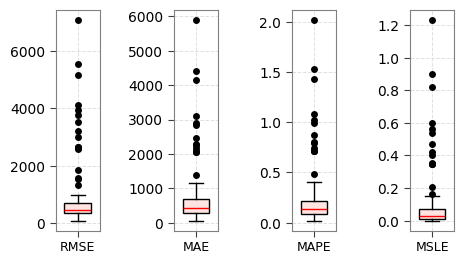

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape,
    'MSLE': msle
})

# 1 row, 4 columns of subplots (independent y-axis scales)
fig, axes = plt.subplots(1, 4, figsize=(5, 3), facecolor='white')

for ax, col in zip(axes, df.columns):
    ax.set_facecolor('white')
    ax.boxplot(df[col],
               widths=0.6,  # <- This increases the box width
               patch_artist=True,
               boxprops=dict(facecolor='mistyrose', color='black', linewidth=1),
               whiskerprops=dict(color='black', linestyle='-', linewidth=1),
               capprops=dict(color='black', linewidth=1),
               medianprops=dict(color='red', linewidth=1),
               flierprops=dict(marker='o', markersize=5,
                               markerfacecolor='black', markeredgecolor='none'))

    #ax.set_title(col, fontsize=11, fontweight='medium')
    ax.set_xticks([1])
    ax.set_xticklabels([col], fontsize=9)
    ax.tick_params(axis='both', which='major', length=4, width=0.8, color='#404040')
    ax.grid(True, linestyle='--', linewidth=0.7, color='#e0e0e0')

    # Clean spine color
    for spine in ax.spines.values():
        spine.set_color('#808080')

#fig.text(0.5, -0.02, 'Metrics', ha='center', fontsize=10)
plt.tight_layout(pad=2)
plt.savefig('metrics_boxplots_widebars.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# Plot Results

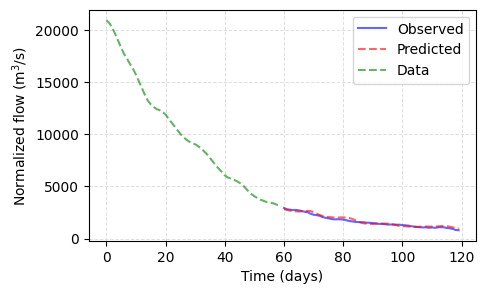

In [ ]:
last_points_train = X_test[0].reshape(-1, 1).flatten()

# plotting
index_x = np.arange(len(last_points_train))
index_x_2 = index_x + window_size
plt.figure(figsize=(5, 3))
plt.plot(index_x_2, y_test[:window_size], label='Observed', color='blue', alpha=0.6)
plt.plot(index_x_2, test_part, label='Predicted', color='red', alpha=0.6, linestyle='--')

# plot the X_train[-1] values
plt.plot(index_x, last_points_train, label='Data', color='green', alpha=0.6, linestyle='--')
#plt.title('Time Series Prediction: Observed vs Predicted')
plt.xlabel('Time (days)')
plt.ylabel('Normalized flow (m$^3$/s)')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.7, color='#e0e0e0')
plt.savefig('comp3.pdf', dpi=300, bbox_inches='tight')
plt.show()

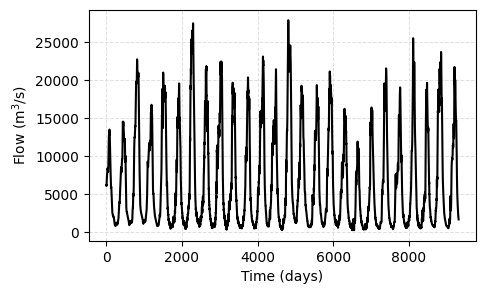

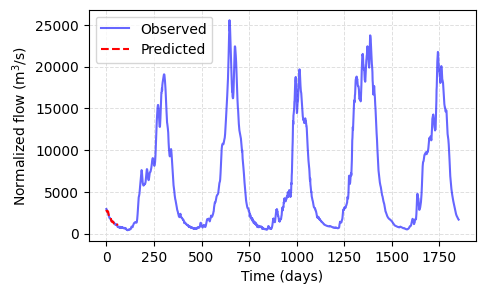

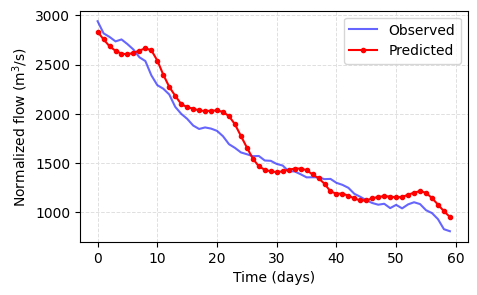

In [ ]:
# # Plotting observed vs predicted values
plt.figure(figsize=(5, 3))
plt.plot(data, label='Observed', color='k')
#plt.title('Time Series Prediction: Observed vs Predicted')
plt.xlabel('Time (days)')
plt.ylabel('Flow (m$^3$/s)')
plt.grid(True, linestyle='--', linewidth=0.7, color='#e0e0e0')
plt.savefig('or.pdf', dpi=300, bbox_inches='tight')
plt.show()

# # Plotting observed vs predicted values
plt.figure(figsize=(5, 3))
plt.plot(y_test, label='Observed', color='blue', alpha=0.6)
plt.plot(y_pred, label='Predicted', color='red', linestyle='--')
#plt.title('Time Series Prediction: Observed vs Predicted')
plt.xlabel('Time (days)')
plt.ylabel('Normalized flow (m$^3$/s)')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.7, color='#e0e0e0')
plt.savefig('comp1.pdf', dpi=300, bbox_inches='tight')
plt.show()

# # Optionally plot a zoomed-in portion
plt.figure(figsize=(5, 3))
zoom_range = window_size  # Plot first points of test set
plt.plot(y_test[:zoom_range], label='Observed', color='blue', alpha=0.6)
plt.plot(y_pred[:zoom_range], label='Predicted', color='red', marker='o', markersize=3)
#plt.title('Zoomed Comparison: Observed vs Predicted')
plt.xlabel('Time (days)')
plt.ylabel('Normalized flow (m$^3$/s)')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.7, color='#e0e0e0')
plt.savefig('comp2.pdf', dpi=300, bbox_inches='tight')
plt.show()